## 1. Project Overview
Research Question

How has the UK electricity system transformed between 2009 and 2026, and what evidence demonstrates progress towards a lower-carbon energy future?

Objectives
Analyse changes in electricity generation sources.
Assess progress towards decarbonisation.
Examine the characteristics of the modern UK electricity system.

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("../data/df_fuel_ckan.csv")

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303389 entries, 0 to 303388
Data columns (total 34 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   DATETIME          303389 non-null  str    
 1   GAS               303389 non-null  float64
 2   COAL              303389 non-null  float64
 3   NUCLEAR           303389 non-null  float64
 4   WIND              303389 non-null  float64
 5   WIND_EMB          303389 non-null  float64
 6   HYDRO             303389 non-null  int64  
 7   IMPORTS           303389 non-null  float64
 8   BIOMASS           303389 non-null  float64
 9   OTHER             303389 non-null  float64
 10  SOLAR             303389 non-null  float64
 11  STORAGE           303389 non-null  int64  
 12  GENERATION        303389 non-null  float64
 13  CARBON_INTENSITY  303389 non-null  float64
 14  LOW_CARBON        303389 non-null  float64
 15  ZERO_CARBON       303389 non-null  float64
 16  RENEWABLE         303389 non-nu

In [5]:
df.columns

Index(['DATETIME', 'GAS', 'COAL', 'NUCLEAR', 'WIND', 'WIND_EMB', 'HYDRO',
       'IMPORTS', 'BIOMASS', 'OTHER', 'SOLAR', 'STORAGE', 'GENERATION',
       'CARBON_INTENSITY', 'LOW_CARBON', 'ZERO_CARBON', 'RENEWABLE', 'FOSSIL',
       'GAS_perc', 'COAL_perc', 'NUCLEAR_perc', 'WIND_perc', 'WIND_EMB_perc',
       'HYDRO_perc', 'IMPORTS_perc', 'BIOMASS_perc', 'OTHER_perc',
       'SOLAR_perc', 'STORAGE_perc', 'GENERATION_perc', 'LOW_CARBON_perc',
       'ZERO_CARBON_perc', 'RENEWABLE_perc', 'FOSSIL_perc'],
      dtype='str')

In [17]:
df.isna().sum()

DATETIME            0
GAS                 0
COAL                0
NUCLEAR             0
WIND                0
WIND_EMB            0
HYDRO               0
IMPORTS             0
BIOMASS             0
OTHER               0
SOLAR               0
STORAGE             0
GENERATION          0
CARBON_INTENSITY    0
LOW_CARBON          0
ZERO_CARBON         0
RENEWABLE           0
FOSSIL              0
GAS_perc            0
COAL_perc           0
NUCLEAR_perc        0
WIND_perc           0
WIND_EMB_perc       0
HYDRO_perc          0
IMPORTS_perc        0
BIOMASS_perc        0
OTHER_perc          0
SOLAR_perc          0
STORAGE_perc        0
GENERATION_perc     0
LOW_CARBON_perc     0
ZERO_CARBON_perc    0
RENEWABLE_perc      0
FOSSIL_perc         0
YEAR                0
dtype: int64

In [18]:
df.duplicated().sum()

np.int64(0)

In [19]:
df.dtypes

DATETIME            datetime64[us]
GAS                        float64
COAL                       float64
NUCLEAR                    float64
WIND                       float64
WIND_EMB                   float64
HYDRO                        int64
IMPORTS                    float64
BIOMASS                    float64
OTHER                      float64
SOLAR                      float64
STORAGE                      int64
GENERATION                 float64
CARBON_INTENSITY           float64
LOW_CARBON                 float64
ZERO_CARBON                float64
RENEWABLE                  float64
FOSSIL                     float64
GAS_perc                   float64
COAL_perc                  float64
NUCLEAR_perc               float64
WIND_perc                  float64
WIND_EMB_perc              float64
HYDRO_perc                 float64
IMPORTS_perc               float64
BIOMASS_perc               float64
OTHER_perc                 float64
SOLAR_perc                 float64
STORAGE_perc        

In [20]:
df["DATETIME"] = pd.to_datetime(df["DATETIME"])
df["YEAR"] = df["DATETIME"].dt.year

1. How has generation mix changed from 2009 to 2026?

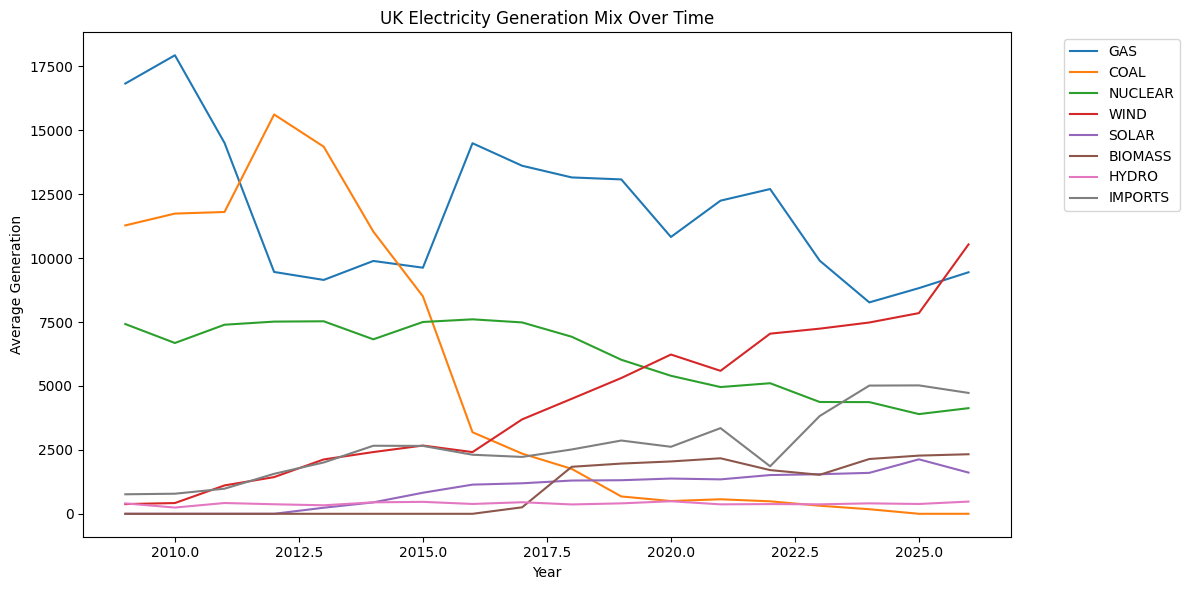

In [7]:
fuel_cols = ["GAS", "COAL", "NUCLEAR", "WIND", "SOLAR", "BIOMASS", "HYDRO", "IMPORTS"]

yearly_generation = df.groupby("YEAR")[fuel_cols].mean()

yearly_generation.plot(figsize=(12,6))
plt.title("UK Electricity Generation Mix Over Time")
plt.xlabel("Year")
plt.ylabel("Average Generation")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

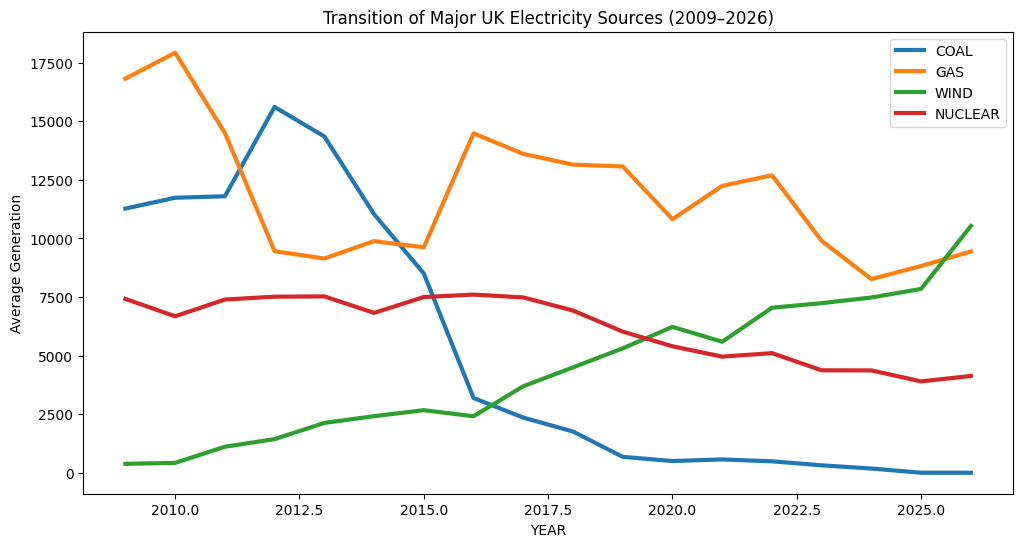

In [10]:
major_sources = [
    "COAL",
    "GAS",
    "WIND",
    "NUCLEAR"
]

yearly_generation[major_sources].plot(
    figsize=(12,6),
    linewidth=3
)

plt.title("Transition of Major UK Electricity Sources (2009–2026)")
plt.ylabel("Average Generation")
plt.show()

2. Which sources increased or declined the most?

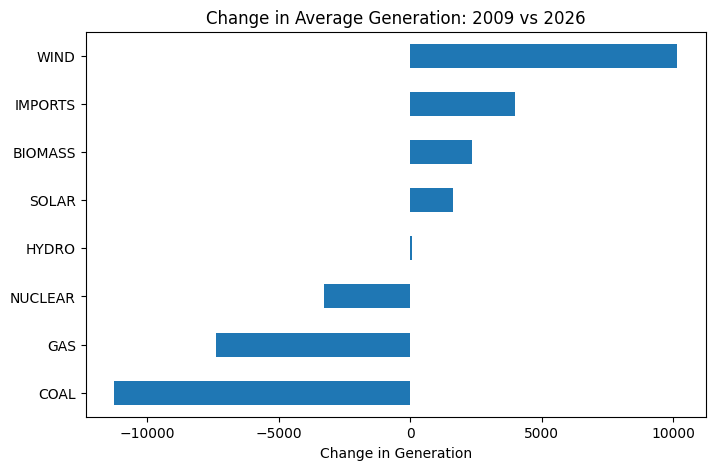

In [8]:
change = yearly_generation.loc[2026] - yearly_generation.loc[2009]
change.sort_values().plot(kind="barh", figsize=(8,5))

plt.title("Change in Average Generation: 2009 vs 2026")
plt.xlabel("Change in Generation")
plt.show()

3. How has carbon intensity changed?

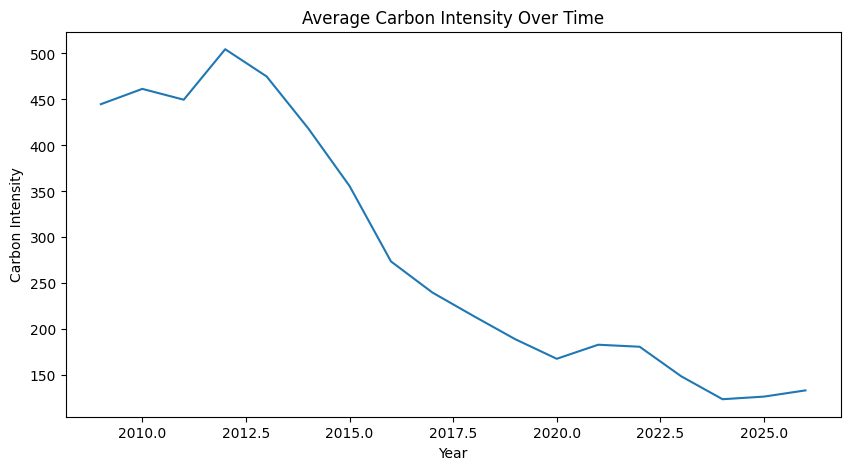

In [9]:
yearly_carbon = df.groupby("YEAR")["CARBON_INTENSITY"].mean()

plt.figure(figsize=(10,5))
plt.plot(yearly_carbon.index, yearly_carbon.values)

plt.title("Average Carbon Intensity Over Time")
plt.xlabel("Year")
plt.ylabel("Carbon Intensity")
plt.show()

4. How have renewable and fossil generation changed?

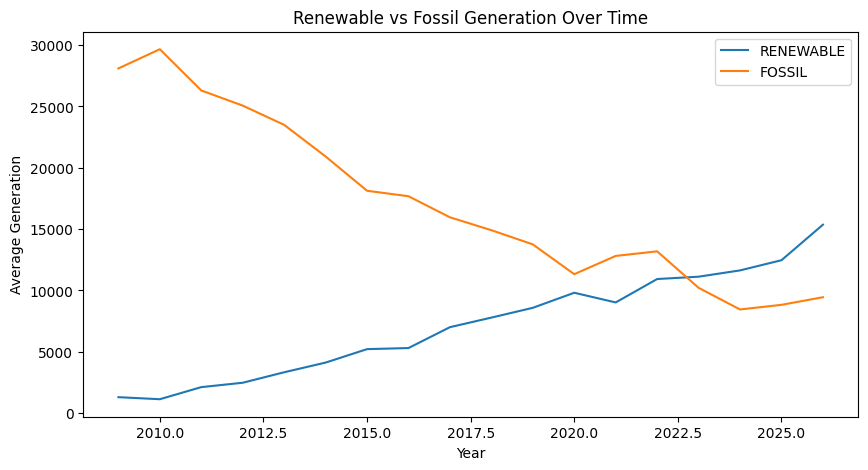

In [12]:
yearly_rf = df.groupby("YEAR")[["RENEWABLE", "FOSSIL"]].mean()

yearly_rf.plot(figsize=(10,5))

plt.title("Renewable vs Fossil Generation Over Time")
plt.xlabel("Year")
plt.ylabel("Average Generation")
plt.show()

5. Is renewable growth linked to lower carbon intensity?

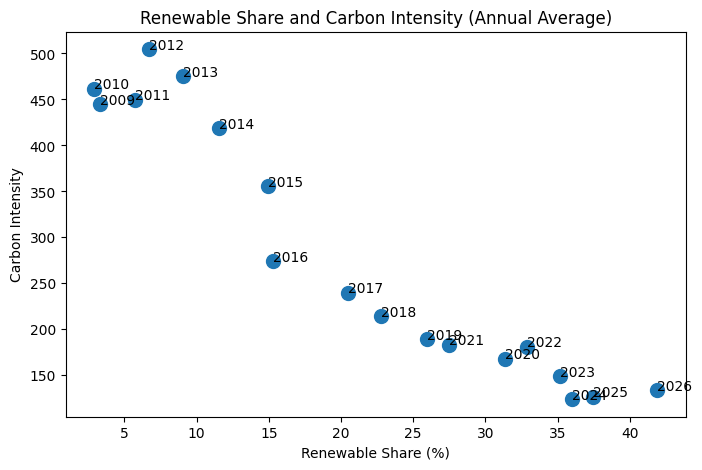

In [16]:
yearly_relationship = (
    df.groupby("YEAR")
      [["RENEWABLE_perc", "CARBON_INTENSITY"]]
      .mean()
)

plt.figure(figsize=(8,5))

plt.scatter(
    yearly_relationship["RENEWABLE_perc"],
    yearly_relationship["CARBON_INTENSITY"],
    s=100
)

for year in yearly_relationship.index:
    plt.annotate(
        year,
        (
            yearly_relationship.loc[year, "RENEWABLE_perc"],
            yearly_relationship.loc[year, "CARBON_INTENSITY"]
        )
    )

plt.xlabel("Renewable Share (%)")
plt.ylabel("Carbon Intensity")
plt.title("Renewable Share and Carbon Intensity (Annual Average)")
plt.show()

6. What does 2026 generation mix look like?

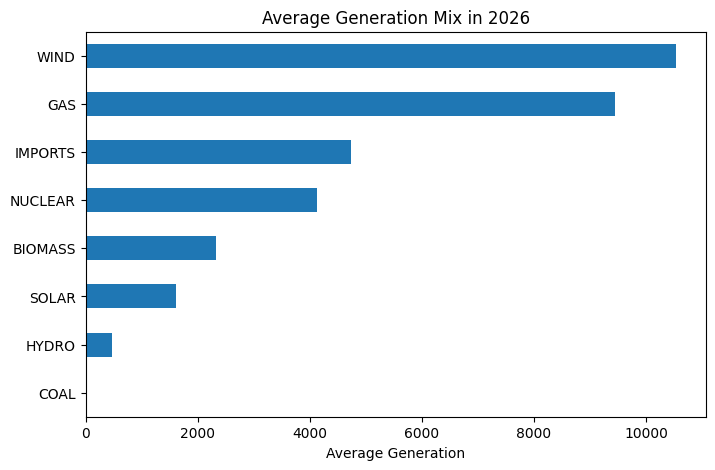

In [14]:
latest_year = df[df["YEAR"] == 2026]

current_mix = latest_year[fuel_cols].mean().sort_values()

current_mix.plot(kind="barh", figsize=(8,5))

plt.title("Average Generation Mix in 2026")
plt.xlabel("Average Generation")
plt.show()

7. How different is 2026 from 2009?

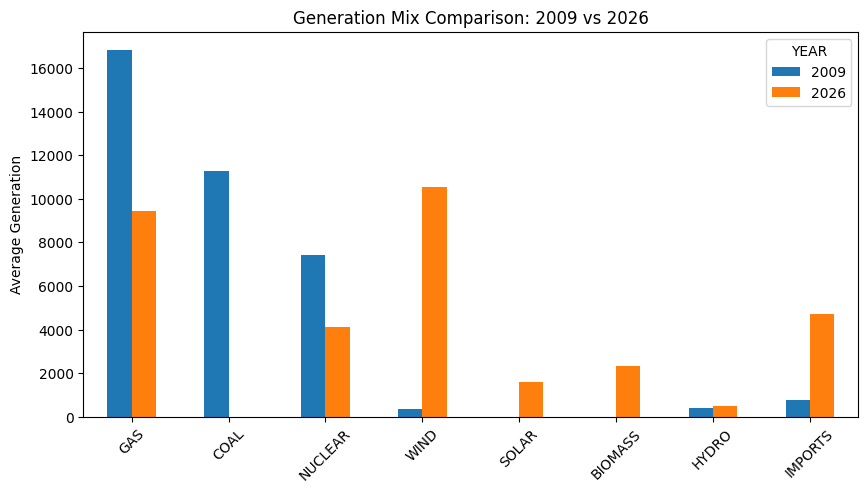

In [15]:
comparison = yearly_generation.loc[[2009, 2026]].T

comparison.plot(kind="bar", figsize=(10,5))

plt.title("Generation Mix Comparison: 2009 vs 2026")
plt.ylabel("Average Generation")
plt.xticks(rotation=45)
plt.show()

## Key Findings

1. Coal generation declined sharply between 2009 and 2026.
2. Wind and solar generation increased significantly over the same period.
3. Renewable generation became a larger part of the UK electricity mix.
4. Carbon intensity reduced as low-carbon and renewable generation increased.
5. Gas remained important, suggesting it still plays a balancing role in the electricity system.